In [1]:
import pandas as pd    
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler


In [2]:
"""1. Data Exploration: (Score : 2)
● Explore the data, list down the unique values in each feature and find its length.
● Perform the statistical analysis and renaming of the columns."""

df = pd.read_csv("Employee.csv")
df.head()

,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0


In [3]:
for col in df.columns:
    print(f"{col}: {df[col].unique()} (Length: {len(df[col].unique())})")

print(df.describe(include='all'))

df.rename(columns=lambda x: x.strip().lower().replace(" ", "_"), inplace=True)

Company: ['TCS' 'Infosys' 'CTS' nan 'Tata Consultancy Services' 'Congnizant'
 'Infosys Pvt Lmt'] (Length: 7)
Age: [20. 30. 35. 40. 23. nan 34. 45. 18. 22. 32. 37. 50. 21. 46. 36. 26. 41.
 24. 25. 43. 19. 38. 51. 31. 44. 33. 17.  0. 54.] (Length: 30)
Salary: [  nan 2300. 3000. 4000. 5000. 6000. 7000. 8000. 9000. 1089. 1234. 3030.
 3045. 3184. 4824. 5835. 7084. 8943. 8345. 9284. 9876. 2034. 7654. 2934.
 4034. 5034. 8202. 9024. 4345. 6544. 6543. 3234. 4324. 5435. 5555. 8787.
 3454. 5654. 5009. 5098. 3033.] (Length: 41)
Place: ['Chennai' 'Mumbai' 'Calcutta' 'Delhi' 'Podicherry' 'Cochin' nan 'Noida'
 'Hyderabad' 'Bhopal' 'Nagpur' 'Pune'] (Length: 12)
Country: ['India'] (Length: 1)
Gender: [0 1] (Length: 2)
       Company         Age       Salary   Place Country      Gender
count      140  130.000000   124.000000     134     148  148.000000
unique       6         NaN          NaN      11       1         NaN
top        TCS         NaN          NaN  Mumbai   India         NaN
freq        53   

In [5]:
"""Data Cleaning: (Score : 2)
● Find the missing and inappropriate values, treat them appropriately.
● Remove all duplicate rows.
● Find the outliers.
● Replace the value 0 in age as NaN Treat the null values in all columns using any
measures(removing/ replace the values with mean/median/mode)"""

print(df.isnull().sum())

df['age'] = df['age'].replace(0, np.nan)

for col in df.select_dtypes(include='number').columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

df = df.drop_duplicates()

Q1 = df['salary'].quantile(0.25)
Q3 = df['salary'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['salary'] < Q1 - 1.5*IQR) | (df['salary'] > Q3 + 1.5*IQR)]
print(outliers)

company    0
age        0
salary     0
place      0
country    0
gender     0
dtype: int64
Empty DataFrame
Columns: [company, age, salary, place, country, gender]
Index: []


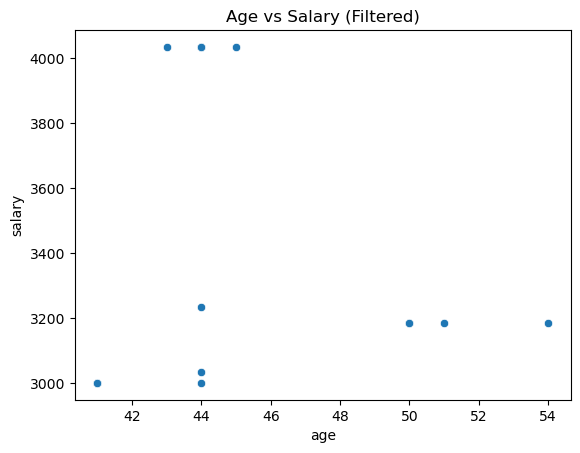

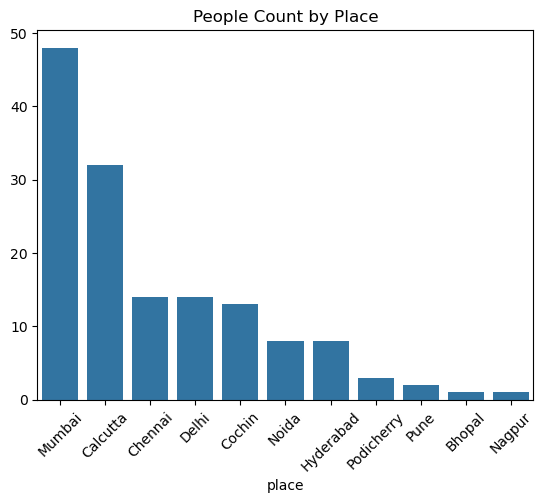

In [6]:
"""● Filter the data with age >40 and salary<5000 Plot the chart with age and salary
Count the number of people from each place and represent it visually"""

filtered = df[(df['age'] > 40) & (df['salary'] < 5000)]
sns.scatterplot(x='age', y='salary', data=filtered)
plt.title("Age vs Salary (Filtered)")
plt.show()

place_counts = df['place'].value_counts()
sns.barplot(x=place_counts.index, y=place_counts.values)
plt.title("People Count by Place")
plt.xticks(rotation=45)
plt.show()

In [13]:

df.columns = df.columns.str.strip().str.lower()

# Label encode gender if present
if 'gender' in df.columns:
    df['gender'] = LabelEncoder().fit_transform(df['gender'])

# Automatically one-hot encode all object (categorical) columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(df.head())

    age  salary  gender  place_calcutta  place_chennai  place_cochin  \
0  20.0  5000.0       0           False           True         False   
1  30.0  5000.0       0           False          False         False   
2  35.0  2300.0       0            True          False         False   
3  40.0  3000.0       0           False          False         False   
4  23.0  4000.0       0           False          False         False   

   place_delhi  place_hyderabad  place_mumbai  place_nagpur  place_noida  \
0        False            False         False         False        False   
1        False            False          True         False        False   
2        False            False         False         False        False   
3         True            False         False         False        False   
4        False            False          True         False        False   

   place_podicherry  place_pune  company_congnizant  company_infosys  \
0             False       False       

In [16]:

scaler_standard = StandardScaler()
scaler_minmax = MinMaxScaler()

# Apply scaling
scaled_standard = scaler_standard.fit_transform(df.select_dtypes(include='number'))
scaled_minmax = scaler_minmax.fit_transform(df.select_dtypes(include='number'))

# Convert back to DataFrame
df_standard = pd.DataFrame(scaled_standard, columns=df.select_dtypes(include='number').columns)
df_minmax = pd.DataFrame(scaled_minmax, columns=df.select_dtypes(include='number').columns)


In [17]:
df_standard.head()

,age,salary,gender
0,-1.484676,-0.100827,-0.534522
1,-0.267174,-0.100827,-0.534522
2,0.341577,-1.243735,-0.534522
3,0.950328,-0.947426,-0.534522
4,-1.119426,-0.524127,-0.534522


In [18]:
df_minmax.head()

,age,salary,gender
0,0.081081,0.445089,0.0
1,0.351351,0.445089,0.0
2,0.486486,0.137817,0.0
3,0.621622,0.217480,0.0
4,0.162162,0.331285,0.0
